# 02d — Diagnostic anomalies

Analyse fine des essais douteux repérés au sanity check (02c).

**Pour chaque essai, on regarde** :
1. **Z brut** du barycentre Dos (avant preprocess)
2. **Les 4 marqueurs Dos** séparés sur Z (qui est en cause ?)
3. **signal_final** preprocessed (.npz produit)
4. **Décomposition EMD** complète + IMFs sélectionnées
5. **Spectre Welch** [0-5 Hz]

**Essais douteux à diagnostiquer** :
- `007MoMa / beatmove_adaptatif` — amplitude 270 mm, f_dom 0.75 Hz
- `006MoCa / tempo_random` — f_dom 1.00 Hz (sous-harmonique ?)
- `008RiMo / silence` — amplitude 83 mm, oscillation parasite
- `005DeJe / silence` — pics à 220s
- `005DeJe / beatmove_adaptatif` — amplitude 64 mm

In [1]:
from resilience import paths, participants, config
from resilience.io import loader, writer
from resilience.processing import preprocess
from resilience.processing.preprocess import (
    interpolate_nans, compute_barycenter,
    apply_emd_decomposition, imf_dominant_frequency
)
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
%matplotlib inline

# Tentative d'import direct PyEMD pour avoir les IMFs brutes
try:
    from PyEMD import EMD
    _EMD = EMD()
    EMD_OK = True
except ImportError:
    EMD_OK = False
    print('⚠️  PyEMD pas dispo')

In [2]:
ANOMALIES = [
    ('007MoMa', 'beatmove_adaptatif'),
    ('006MoCa', 'tempo_random'),
    ('008RiMo', 'silence'),
    ('005DeJe', 'silence'),
    ('005DeJe', 'beatmove_adaptatif'),
]

## Fonction de diagnostic complète pour 1 essai

In [3]:
def diagnose(participant, condition):
    print(f"\n{'═'*70}\n  DIAGNOSTIC : {participant} / {condition}\n{'═'*70}")

    # 1. Charger .mat brut (et appliquer crops si présents, comme le batch)
    raw_path = paths.raw_file(participant, condition)
    data, fmt = loader.load_mat(raw_path)
    trajectories = loader.extract_marker_trajectories(data, fmt)

    trial = participants.get_trial(participant, condition)
    n_before = next(iter(trajectories.values())).shape[0]
    i_start = int(trial.crop_start_s * config.FS_RAW) if trial.crop_start_s else 0
    i_end   = int(trial.crop_end_s * config.FS_RAW) if trial.crop_end_s else n_before
    trajectories = {m: xyz[i_start:i_end] for m, xyz in trajectories.items()}

    print(f"  Crops : start={trial.crop_start_s}, end={trial.crop_end_s}")
    print(f"  Frames après crop : {i_end-i_start} ({(i_end-i_start)/config.FS_RAW:.0f}s)")

    # 2. Z brut sacrum + marqueurs Dos séparés
    bary = compute_barycenter(trajectories, center_on_mean=True)
    sacrum_z_raw = bary[:, 2]
    t_raw = np.arange(len(sacrum_z_raw)) / config.FS_RAW

    dos_z = {}
    for m in ('Dos01', 'Dos02', 'Dos03', 'Dos04'):
        z = trajectories[m][:, 2].copy()
        # Sans interpolation pour voir les NaN bruts
        dos_z[m] = z

    # Stats par marqueur
    print(f"\n  Visibilité par marqueur (% non-NaN) :")
    for m, z in dos_z.items():
        valid = np.sum(~np.isnan(z)) / len(z) * 100
        amp = float(np.nanpercentile(z, 95) - np.nanpercentile(z, 5)) if valid > 5 else np.nan
        print(f"    {m} : {valid:.1f}%  | amplitude pic-à-pic = {amp:.1f} mm")

    # 3. Charger le .npz produit
    payload = writer.load_processed(participant, condition)
    sig_final = payload['signal_final']
    t_final   = payload['time_final']

    # 4. Refaire EMD pour avoir les IMFs et la sélection
    if EMD_OK:
        IMFs = _EMD(sacrum_z_raw)
        freqs = [imf_dominant_frequency(imf, config.FS_RAW) for imf in IMFs]
        f_low, f_high = config.WALKING_BAND_HZ
        selected = [i for i, f in enumerate(freqs) if f_low <= f <= f_high]
        print(f"\n  EMD : {len(IMFs)} IMFs")
        for i, f in enumerate(freqs):
            tag = '✓' if i in selected else ' '
            print(f"    [{tag}] IMF{i:2d} : f_dom = {f:.3f} Hz")
        print(f"  Bande [{f_low}-{f_high} Hz] → sélectionnées : {selected}")
    else:
        IMFs = None
        selected = []

    # ═════════════════════════════════════════════════════════════
    # PLOTS
    # ═════════════════════════════════════════════════════════════
    fig = plt.figure(figsize=(14, 16))
    gs = fig.add_gridspec(6, 1, hspace=0.45)

    # Plot A : sacrum Z brut
    ax = fig.add_subplot(gs[0])
    ax.plot(t_raw, sacrum_z_raw, color='steelblue', linewidth=0.4)
    ax.set_title('A. Sacrum Z brut (barycentre Dos01-04, après crops, centré)', loc='left', fontsize=10)
    ax.set_ylabel('Z (mm)')
    ax.grid(alpha=0.3)

    # Plot B : 4 marqueurs Dos séparés sur Z
    ax = fig.add_subplot(gs[1])
    for m, z in dos_z.items():
        # Centrer pour comparaison visuelle
        z_centered = z - np.nanmean(z)
        ax.plot(t_raw, z_centered, linewidth=0.4, label=m, alpha=0.7)
    ax.set_title('B. 4 marqueurs Dos séparés (Z centrés) — identifier le marqueur fautif', loc='left', fontsize=10)
    ax.set_ylabel('Z centré (mm)')
    ax.legend(loc='upper right', fontsize=7, ncol=4)
    ax.grid(alpha=0.3)

    # Plot C : signal_final (preprocessed)
    ax = fig.add_subplot(gs[2])
    ax.plot(t_final, sig_final, color='darkorange', linewidth=0.5)
    ax.set_title('C. signal_final (Z preprocessed, 100 Hz)', loc='left', fontsize=10)
    ax.set_ylabel('Z (mm)')
    ax.grid(alpha=0.3)

    # Plot D : IMFs sélectionnées (somme = ce qui devient sig_final)
    ax = fig.add_subplot(gs[3])
    if IMFs is not None and selected:
        for i in selected:
            ax.plot(t_raw, IMFs[i], linewidth=0.5, alpha=0.7,
                    label=f'IMF{i} ({freqs[i]:.2f}Hz)')
        ax.set_title(f'D. IMFs sélectionnées (somme = signal reconstruit pré-filtrage)',
                     loc='left', fontsize=10)
        ax.legend(fontsize=7, loc='upper right', ncol=min(len(selected), 4))
    else:
        ax.text(0.5, 0.5, 'Pas d\'IMFs disponibles', ha='center', transform=ax.transAxes)
    ax.set_ylabel('Amplitude')
    ax.grid(alpha=0.3)

    # Plot E : IMFs NON sélectionnées (avec leur f_dom)
    ax = fig.add_subplot(gs[4])
    if IMFs is not None:
        non_selected = [i for i in range(len(IMFs)) if i not in selected]
        for i in non_selected[:8]:  # max 8 pour lisibilité
            ax.plot(t_raw, IMFs[i], linewidth=0.4, alpha=0.6,
                    label=f'IMF{i} ({freqs[i]:.2f}Hz)')
        ax.set_title('E. IMFs NON sélectionnées (informatif)', loc='left', fontsize=10)
        ax.legend(fontsize=7, loc='upper right', ncol=4)
    ax.set_ylabel('Amplitude')
    ax.grid(alpha=0.3)

    # Plot F : Spectre Welch du signal_final
    ax = fig.add_subplot(gs[5])
    f, pxx = welch(sig_final, fs=config.FS_CLEAN,
                    nperseg=min(len(sig_final), 4*config.FS_CLEAN))
    ax.semilogy(f, pxx, color='darkorange', linewidth=0.8)
    ax.axvspan(*config.WALKING_BAND_HZ, color='green', alpha=0.1, label='Bande marche')
    mask = (f >= config.WALKING_BAND_HZ[0]) & (f <= config.WALKING_BAND_HZ[1])
    if mask.any():
        f_dom = f[mask][np.argmax(pxx[mask])]
        ax.axvline(f_dom, color='red', linewidth=1, label=f'f_dom = {f_dom:.2f} Hz')
    ax.set_xlim(0, 5)
    ax.set_xlabel('Fréquence (Hz)')
    ax.set_ylabel('PSD')
    ax.set_title('F. Spectre Welch du signal_final', loc='left', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    plt.suptitle(f'Diagnostic : {participant} / {condition}',
                  fontsize=12, fontweight='bold', y=1.0)
    plt.savefig(f'diag_{participant}_{condition}.png', dpi=80, bbox_inches='tight')
    plt.show()

## Diagnostic 1/5 — 007MoMa / beatmove_adaptatif


══════════════════════════════════════════════════════════════════════
  DIAGNOSTIC : 007MoMa / beatmove_adaptatif
══════════════════════════════════════════════════════════════════════
  Crops : start=68, end=350
  Frames après crop : 112800 (282s)

  Visibilité par marqueur (% non-NaN) :
    Dos01 : 97.6%  | amplitude pic-à-pic = 62.0 mm
    Dos02 : 98.2%  | amplitude pic-à-pic = 61.5 mm
    Dos03 : 99.4%  | amplitude pic-à-pic = 754.9 mm
    Dos04 : 86.8%  | amplitude pic-à-pic = 1007.0 mm

  EMD : 20 IMFs
    [ ] IMF 0 : f_dom = 7.500 Hz
    [ ] IMF 1 : f_dom = 45.250 Hz
    [ ] IMF 2 : f_dom = 33.750 Hz
    [ ] IMF 3 : f_dom = 24.000 Hz
    [ ] IMF 4 : f_dom = 19.750 Hz
    [ ] IMF 5 : f_dom = 9.500 Hz
    [ ] IMF 6 : f_dom = 9.250 Hz
    [ ] IMF 7 : f_dom = 5.500 Hz
    [ ] IMF 8 : f_dom = 5.250 Hz
    [ ] IMF 9 : f_dom = 2.750 Hz
    [✓] IMF10 : f_dom = 2.500 Hz
    [✓] IMF11 : f_dom = 2.500 Hz
    [✓] IMF12 : f_dom = 0.750 Hz
    [✓] IMF13 : f_dom = 0.750 Hz
    [ ] IMF14 : f_

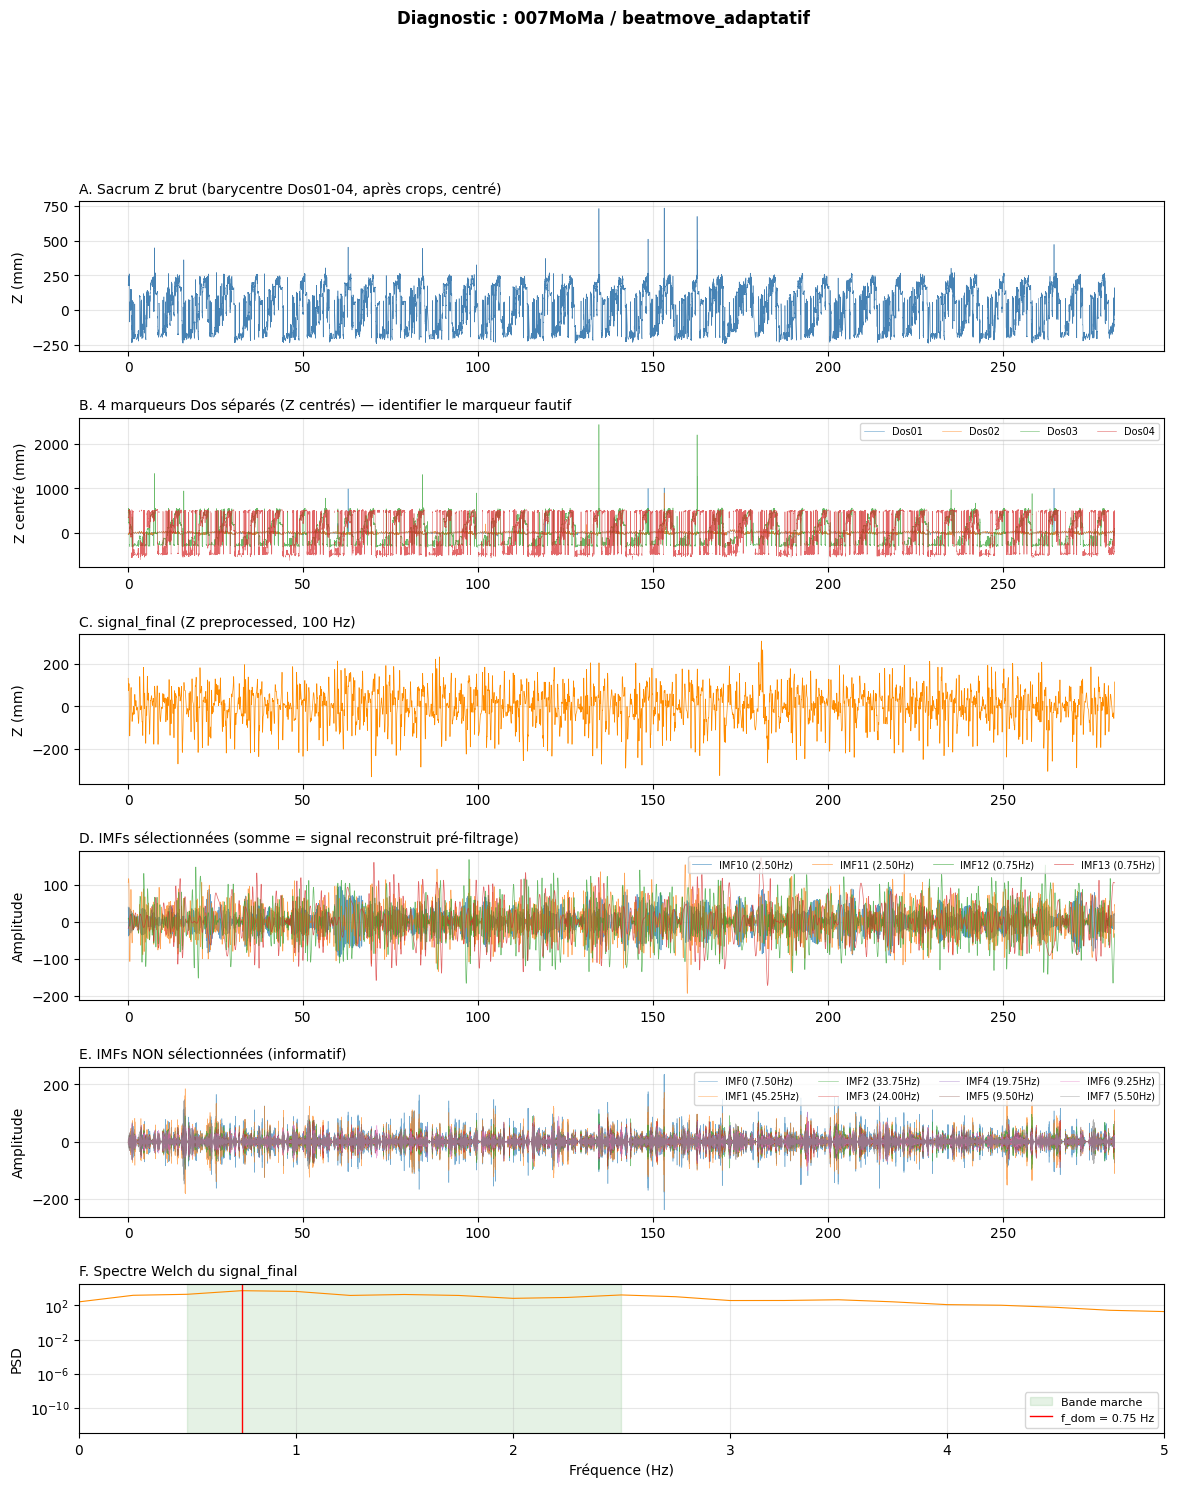

In [4]:
diagnose('007MoMa', 'beatmove_adaptatif')

## Diagnostic 2/5 — 006MoCa / tempo_random


══════════════════════════════════════════════════════════════════════
  DIAGNOSTIC : 006MoCa / tempo_random
══════════════════════════════════════════════════════════════════════
  Crops : start=None, end=305
  Frames après crop : 122000 (305s)

  Visibilité par marqueur (% non-NaN) :
    Dos01 : 98.8%  | amplitude pic-à-pic = 65.7 mm
    Dos02 : 99.1%  | amplitude pic-à-pic = 65.0 mm
    Dos03 : 99.0%  | amplitude pic-à-pic = 184.6 mm
    Dos04 : 97.0%  | amplitude pic-à-pic = 231.8 mm

  EMD : 19 IMFs
    [ ] IMF 0 : f_dom = 4.250 Hz
    [ ] IMF 1 : f_dom = 47.500 Hz
    [ ] IMF 2 : f_dom = 40.500 Hz
    [ ] IMF 3 : f_dom = 24.250 Hz
    [ ] IMF 4 : f_dom = 21.250 Hz
    [✓] IMF 5 : f_dom = 2.000 Hz
    [✓] IMF 6 : f_dom = 2.000 Hz
    [✓] IMF 7 : f_dom = 2.000 Hz
    [✓] IMF 8 : f_dom = 1.750 Hz
    [✓] IMF 9 : f_dom = 0.750 Hz
    [✓] IMF10 : f_dom = 2.000 Hz
    [✓] IMF11 : f_dom = 1.000 Hz
    [✓] IMF12 : f_dom = 1.000 Hz
    [✓] IMF13 : f_dom = 0.500 Hz
    [ ] IMF14 : f_dom =

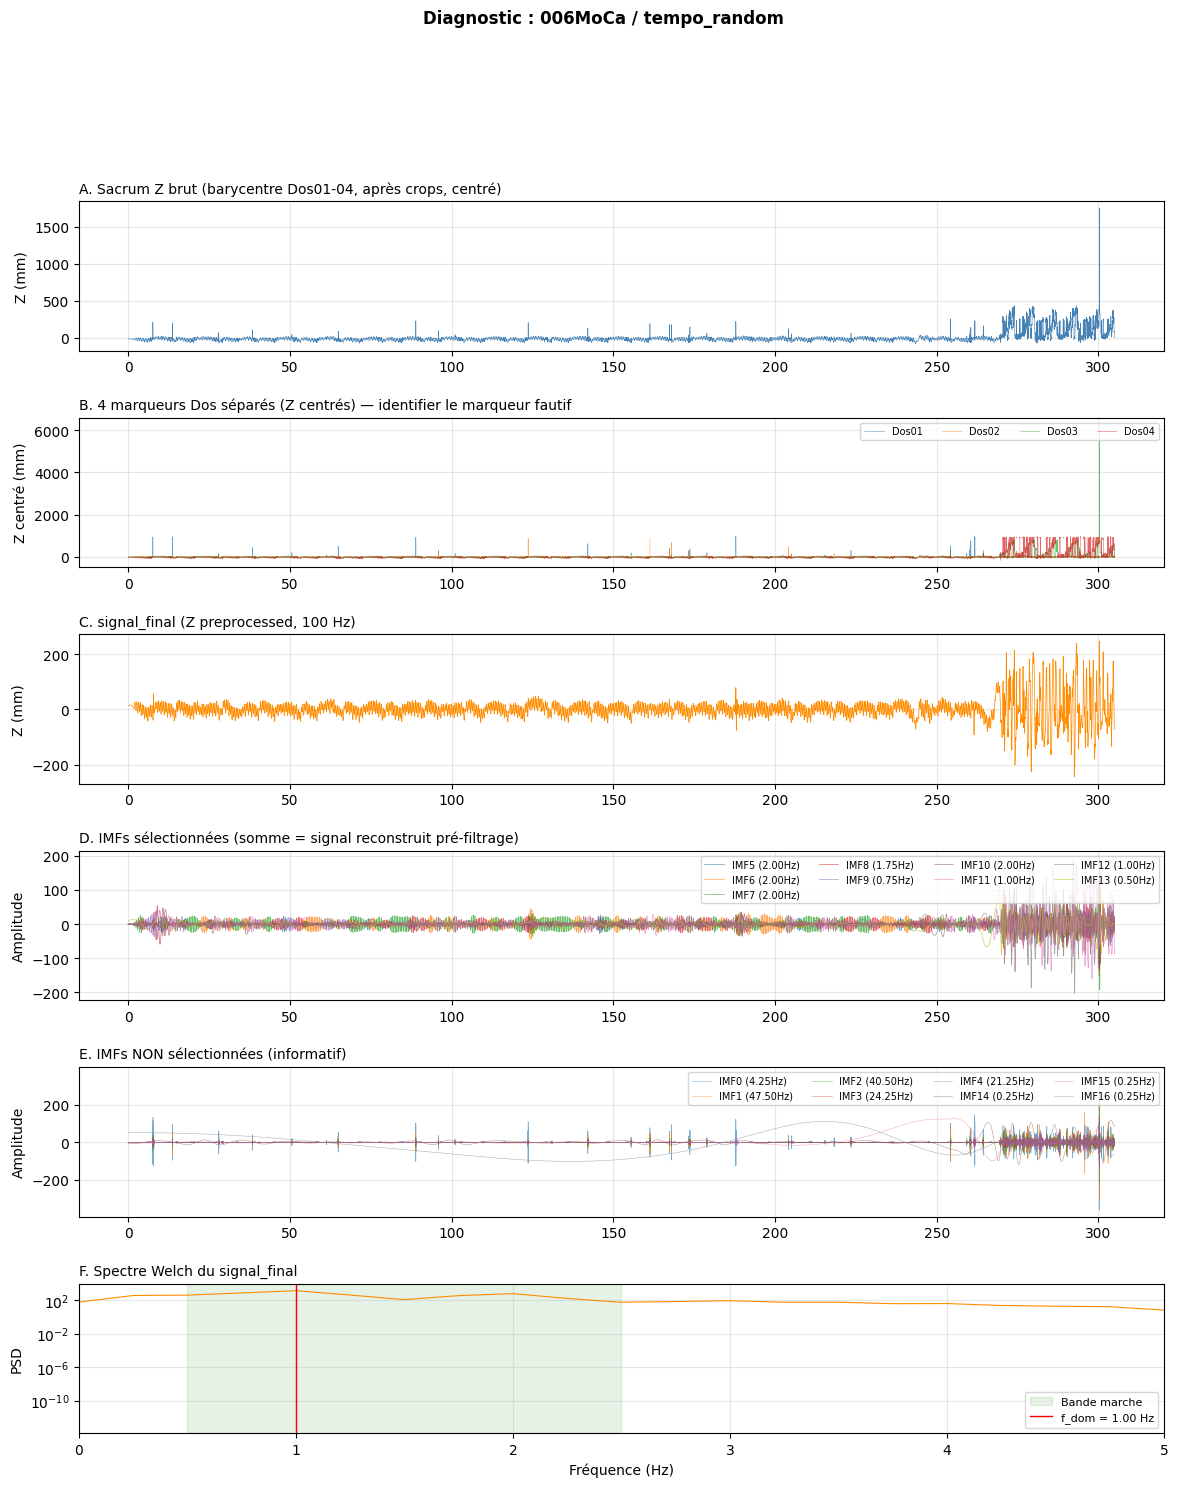

In [5]:
diagnose('006MoCa', 'tempo_random')

## Diagnostic 3/5 — 008RiMo / silence


══════════════════════════════════════════════════════════════════════
  DIAGNOSTIC : 008RiMo / silence
══════════════════════════════════════════════════════════════════════
  Crops : start=None, end=None
  Frames après crop : 192001 (480s)

  Visibilité par marqueur (% non-NaN) :
    Dos01 : 90.9%  | amplitude pic-à-pic = 96.3 mm
    Dos02 : 91.6%  | amplitude pic-à-pic = 97.0 mm
    Dos03 : 91.9%  | amplitude pic-à-pic = 95.9 mm
    Dos04 : 92.0%  | amplitude pic-à-pic = 95.3 mm

  EMD : 21 IMFs
    [ ] IMF 0 : f_dom = 4.000 Hz
    [ ] IMF 1 : f_dom = 11.500 Hz
    [ ] IMF 2 : f_dom = 6.500 Hz
    [ ] IMF 3 : f_dom = 14.500 Hz
    [ ] IMF 4 : f_dom = 12.000 Hz
    [✓] IMF 5 : f_dom = 1.750 Hz
    [✓] IMF 6 : f_dom = 1.750 Hz
    [✓] IMF 7 : f_dom = 1.750 Hz
    [✓] IMF 8 : f_dom = 1.750 Hz
    [✓] IMF 9 : f_dom = 1.750 Hz
    [✓] IMF10 : f_dom = 1.750 Hz
    [ ] IMF11 : f_dom = 0.250 Hz
    [ ] IMF12 : f_dom = 0.250 Hz
    [✓] IMF13 : f_dom = 0.750 Hz
    [ ] IMF14 : f_dom = 0.250 

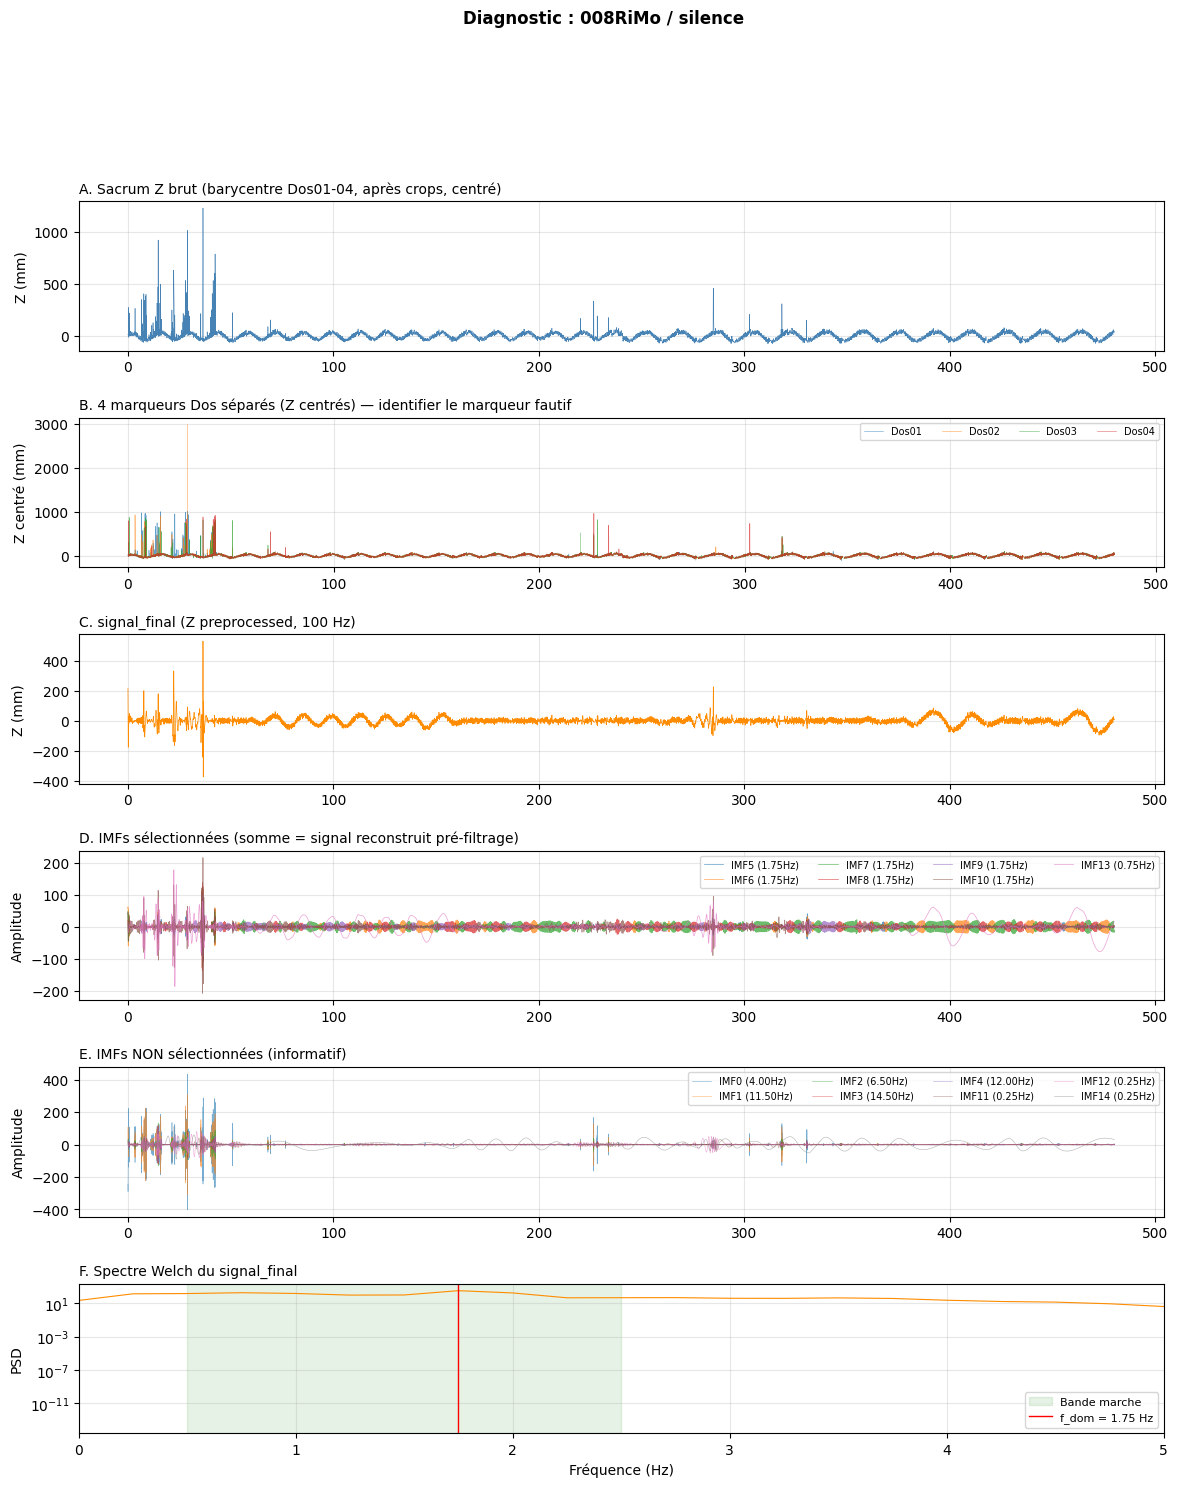

In [6]:
diagnose('008RiMo', 'silence')

## Diagnostic 4/5 — 005DeJe / silence


══════════════════════════════════════════════════════════════════════
  DIAGNOSTIC : 005DeJe / silence
══════════════════════════════════════════════════════════════════════
  Crops : start=None, end=430
  Frames après crop : 172000 (430s)

  Visibilité par marqueur (% non-NaN) :
    Dos01 : 93.2%  | amplitude pic-à-pic = 81.8 mm
    Dos02 : 95.5%  | amplitude pic-à-pic = 82.2 mm
    Dos03 : 96.0%  | amplitude pic-à-pic = 82.6 mm
    Dos04 : 94.0%  | amplitude pic-à-pic = 77.6 mm

  EMD : 20 IMFs
    [ ] IMF 0 : f_dom = 5.500 Hz
    [ ] IMF 1 : f_dom = 33.750 Hz
    [ ] IMF 2 : f_dom = 5.750 Hz
    [ ] IMF 3 : f_dom = 11.500 Hz
    [ ] IMF 4 : f_dom = 7.750 Hz
    [✓] IMF 5 : f_dom = 1.750 Hz
    [✓] IMF 6 : f_dom = 2.000 Hz
    [✓] IMF 7 : f_dom = 1.750 Hz
    [✓] IMF 8 : f_dom = 1.750 Hz
    [✓] IMF 9 : f_dom = 1.750 Hz
    [✓] IMF10 : f_dom = 1.750 Hz
    [✓] IMF11 : f_dom = 0.500 Hz
    [ ] IMF12 : f_dom = 0.250 Hz
    [ ] IMF13 : f_dom = 0.250 Hz
    [ ] IMF14 : f_dom = 0.250 Hz

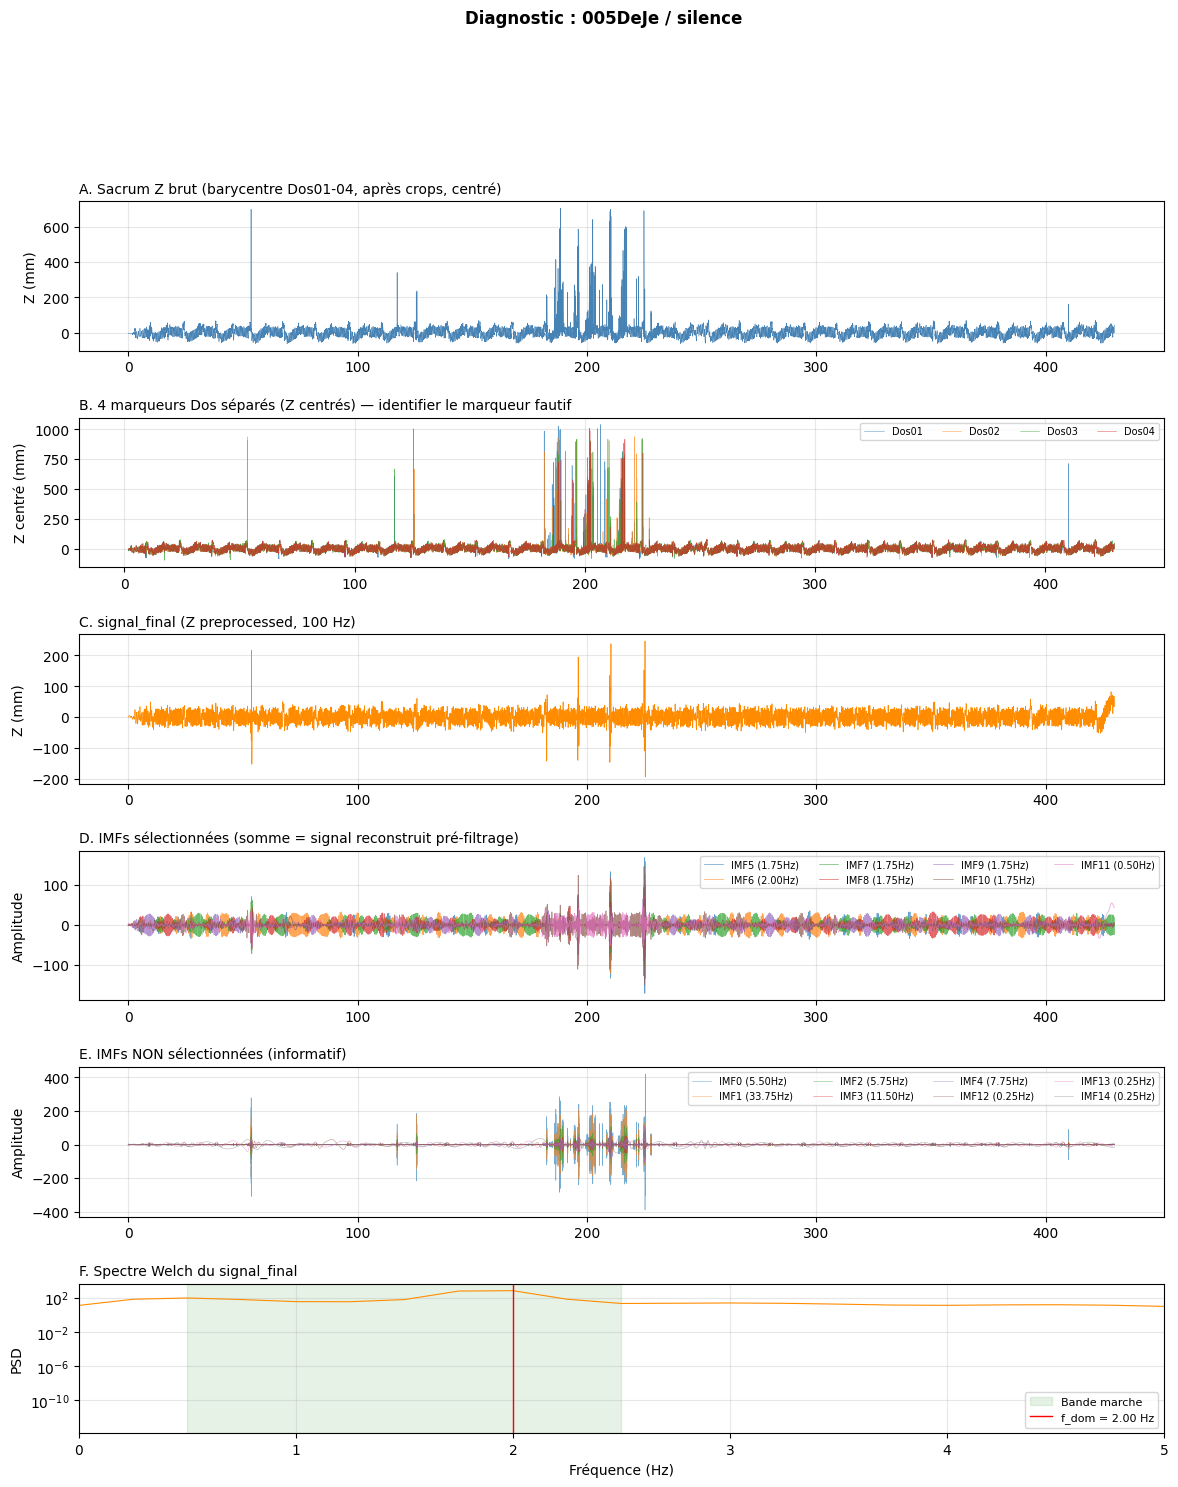

In [7]:
diagnose('005DeJe', 'silence')

## Diagnostic 5/5 — 005DeJe / beatmove_adaptatif


══════════════════════════════════════════════════════════════════════
  DIAGNOSTIC : 005DeJe / beatmove_adaptatif
══════════════════════════════════════════════════════════════════════
  Crops : start=None, end=330
  Frames après crop : 132000 (330s)

  Visibilité par marqueur (% non-NaN) :
    Dos01 : 92.4%  | amplitude pic-à-pic = 92.5 mm
    Dos02 : 92.7%  | amplitude pic-à-pic = 94.5 mm
    Dos03 : 94.7%  | amplitude pic-à-pic = 88.0 mm
    Dos04 : 94.1%  | amplitude pic-à-pic = 87.2 mm

  EMD : 17 IMFs
    [ ] IMF 0 : f_dom = 0.250 Hz
    [ ] IMF 1 : f_dom = 39.500 Hz
    [ ] IMF 2 : f_dom = 39.750 Hz
    [✓] IMF 3 : f_dom = 0.500 Hz
    [ ] IMF 4 : f_dom = 22.500 Hz
    [✓] IMF 5 : f_dom = 1.750 Hz
    [✓] IMF 6 : f_dom = 1.750 Hz
    [✓] IMF 7 : f_dom = 1.750 Hz
    [✓] IMF 8 : f_dom = 1.750 Hz
    [✓] IMF 9 : f_dom = 0.750 Hz
    [ ] IMF10 : f_dom = 0.250 Hz
    [ ] IMF11 : f_dom = 0.250 Hz
    [ ] IMF12 : f_dom = 0.250 Hz
    [ ] IMF13 : f_dom = 0.250 Hz
    [ ] IMF14 : f_do

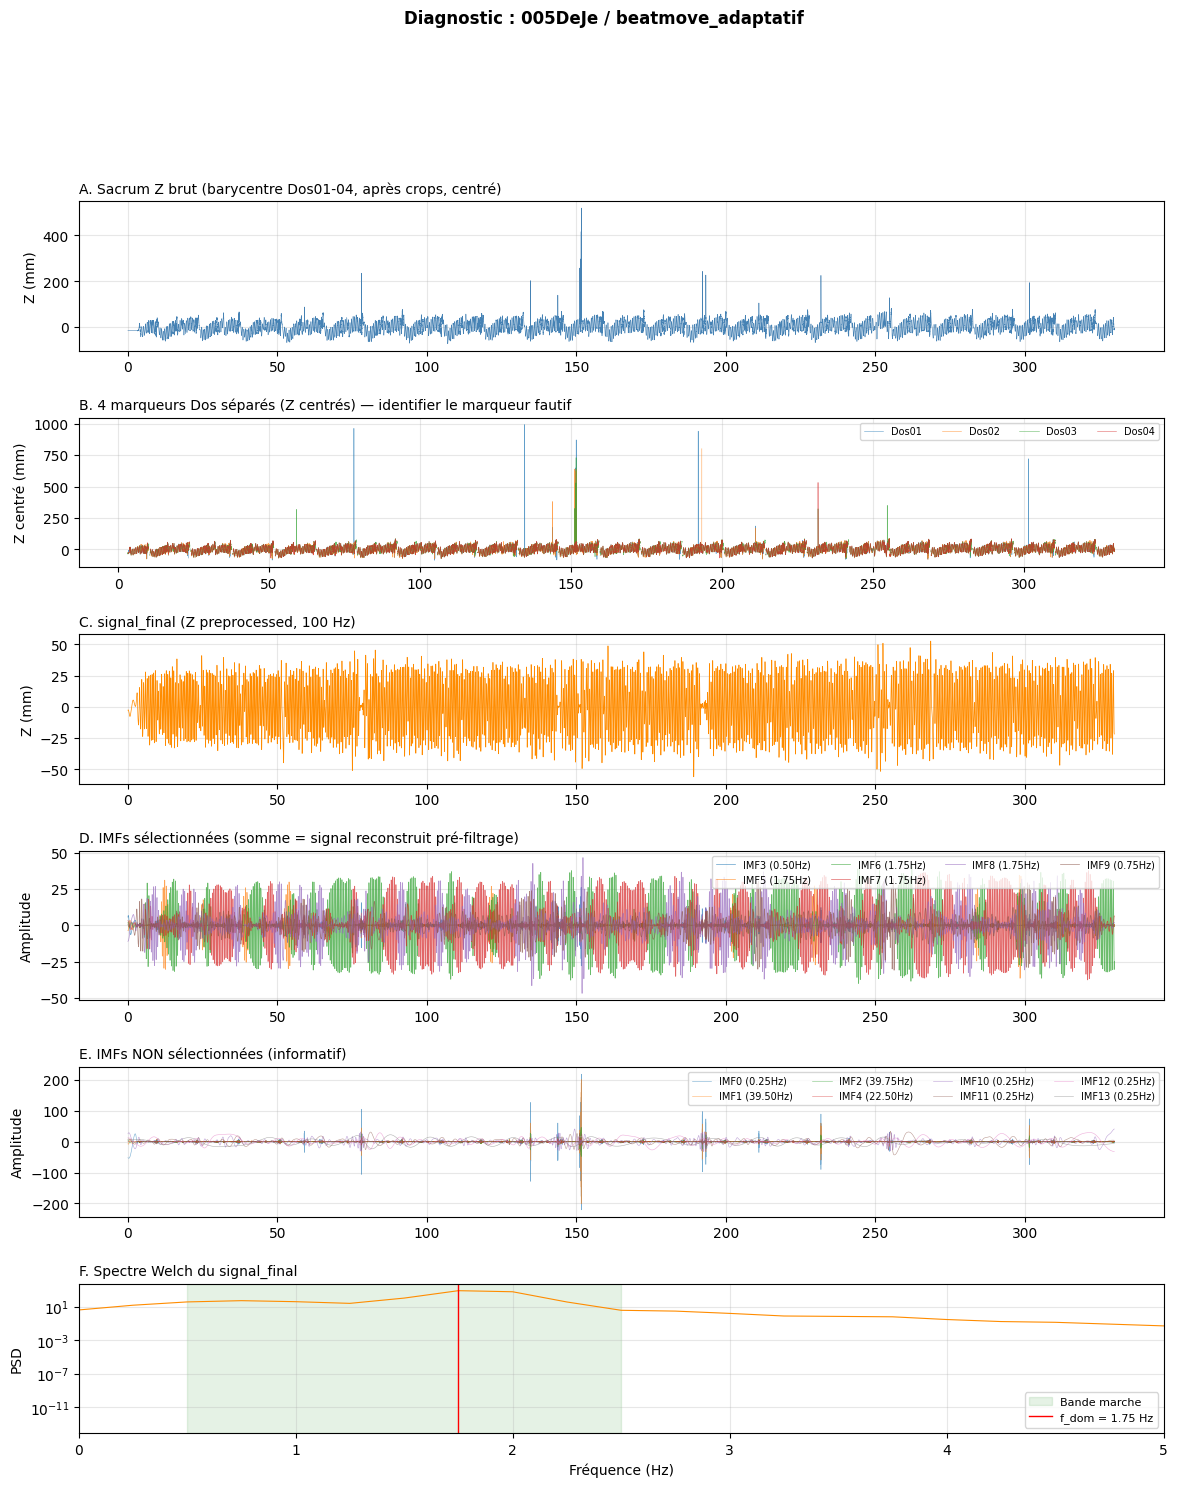

In [8]:
diagnose('005DeJe', 'beatmove_adaptatif')

## Test rapide : P006 / tempo_random avec band_hz=(1.0, 2.5)

Vérifier si une bande resserrée résout le problème de sous-harmonique.

   → compute_barycenter()
   → apply_emd_decomposition()
   Fréquences IMFs : IMF0=4.25Hz, IMF1=47.50Hz, IMF2=40.50Hz, IMF3=24.25Hz, IMF4=21.25Hz, IMF5=2.00Hz, IMF6=2.00Hz, IMF7=2.00Hz, IMF8=1.75Hz, IMF9=0.75Hz, IMF10=2.00Hz, IMF11=1.00Hz, IMF12=1.00Hz, IMF13=0.50Hz, IMF14=0.25Hz, IMF15=0.25Hz, IMF16=0.25Hz, IMF17=0.25Hz, IMF18=0.25Hz
   Bande [1.0–2.5 Hz] → IMFs sélectionnées : [5, 6, 7, 8, 10, 11, 12]
   EMD : 19 IMFs extraites, mode='auto', gardées=[5, 6, 7, 8, 10, 11, 12]
   → butterworth_filter(cutoff=5.0 Hz, order=4)
   → downsample_signal(factor=4)  |  400 → 100 Hz


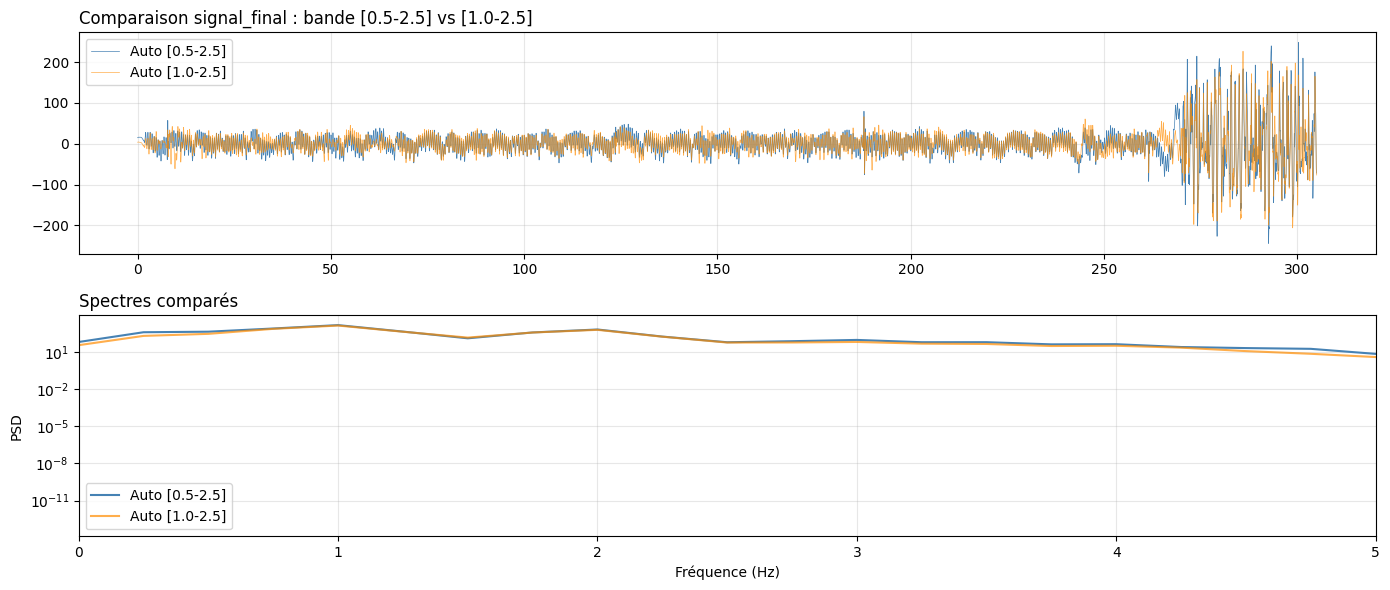


  f_dom : 1.00 Hz → 1.00 Hz
  amplitude : 80.6 mm → 73.3 mm


In [9]:
# Charger le brut
raw_path = paths.raw_file('006MoCa', 'tempo_random')
data, fmt = loader.load_mat(raw_path)
trajectories = loader.extract_marker_trajectories(data, fmt)
trial = participants.get_trial('006MoCa', 'tempo_random')
i_end = int(trial.crop_end_s * config.FS_RAW)
trajectories = {m: xyz[:i_end] for m, xyz in trajectories.items()}

# Reprocesser avec bande resserrée
out_tight = preprocess.run(trajectories, axis='Z',
                              band_hz=(1.0, 2.5), verbose=True)

# Comparer ancien vs nouveau
sig_old = writer.load_processed('006MoCa', 'tempo_random')['signal_final']
sig_new = out_tight['signal_final']
t = out_tight['time_final']

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].plot(t, sig_old, color='steelblue', linewidth=0.5, label='Auto [0.5-2.5]')
axes[0].plot(t, sig_new, color='darkorange', linewidth=0.5, label='Auto [1.0-2.5]', alpha=0.7)
axes[0].set_title('Comparaison signal_final : bande [0.5-2.5] vs [1.0-2.5]', loc='left')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Spectres
f1, p1 = welch(sig_old, fs=config.FS_CLEAN, nperseg=400)
f2, p2 = welch(sig_new, fs=config.FS_CLEAN, nperseg=400)
axes[1].semilogy(f1, p1, color='steelblue', label='Auto [0.5-2.5]')
axes[1].semilogy(f2, p2, color='darkorange', label='Auto [1.0-2.5]', alpha=0.7)
axes[1].set_xlim(0, 5)
axes[1].set_xlabel('Fréquence (Hz)')
axes[1].set_ylabel('PSD')
axes[1].set_title('Spectres comparés', loc='left')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

f_old = f1[(f1>=0.5)&(f1<=2.5)][np.argmax(p1[(f1>=0.5)&(f1<=2.5)])]
f_new = f2[(f2>=0.5)&(f2<=2.5)][np.argmax(p2[(f2>=0.5)&(f2<=2.5)])]
amp_old = float(np.percentile(sig_old, 95) - np.percentile(sig_old, 5))
amp_new = float(np.percentile(sig_new, 95) - np.percentile(sig_new, 5))
print(f'\n  f_dom : {f_old:.2f} Hz → {f_new:.2f} Hz')
print(f'  amplitude : {amp_old:.1f} mm → {amp_new:.1f} mm')